In [36]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix, roc_auc_score,precision_recall_curve,average_precision_score,roc_curve,f1_score
import matplotlib.pyplot as plt
import warnings

import shap

import seaborn as sns
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec
import xgboost as xgb
from sklearn.metrics import (
    precision_score, 
    recall_score, 
)

warnings.filterwarnings('ignore')

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


# NN Learning Curve (train vs. val) --- No Overfitting plot

In [3]:
df = pd.read_parquet('../../data/processed/engineered_features_nn.parquet')

In [4]:
if 'gsr_count' in df.columns:
    df = df.drop(columns=['gsr_count'])
    print('Dropped gsr_count')

meta_cols = ['stub_id', 'particle_id', 'label', 'target', 'final_class']
feature_cols = [c for c in df.columns if c not in meta_cols]

print(f'Shape: {df.shape}')
print(f'Features: {len(feature_cols)}')
print(f'Label distribution:\n{df["label"].value_counts()}')

Dropped gsr_count
Shape: (2294985, 61)
Features: 56
Label distribution:
label
Non_GSR    1216039
GSR        1078946
Name: count, dtype: int64


## Group-Aware Train/Val/Test Split

In [5]:
X = df[feature_cols].values.astype(np.float32)
y = df['target'].values.astype(np.float32)
groups = df['stub_id'].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, y, groups))
X_trainval, X_test_raw = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx_rel, val_idx_rel = next(gss2.split(X_trainval, y_trainval, groups_trainval))
X_train_raw = X_trainval[train_idx_rel]
X_val_raw = X_trainval[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]
groups_train = groups_trainval[train_idx_rel]

In [6]:
train_stubs = set(groups_train)
val_stubs = set(groups_trainval[val_idx_rel])
test_stubs = set(groups[test_idx])

assert len(train_stubs & val_stubs) == 0
assert len(train_stubs & test_stubs) == 0
assert len(val_stubs & test_stubs) == 0
print(f'Train: {len(X_train_raw):,} ({y_train.mean():.1%} GSR)')
print(f'Val: {len(X_val_raw):,} ({y_val.mean():.1%} GSR)')
print(f'Test: {len(X_test_raw):,} ({y_test.mean():.1%} GSR)')
print('No stub overlap confirmed.')

Train: 1,444,147 (49.7% GSR)
Val: 407,614 (37.1% GSR)
Test: 443,224 (47.4% GSR)
No stub overlap confirmed.


In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

## MLP Architecture (Tunable)

In [8]:
class TunableMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, n_layers=2, dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for _ in range(n_layers):
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [9]:
def train_model(X_tr, y_tr, X_vl, y_vl, input_dim,
                hidden_dim=256, n_layers=2, dropout=0.3,
                lr=0.001, batch_size=4096, max_epochs=15, patience=5):
    """Train MLP with given hyperparameters, return best model state and metrics."""
    model = TunableMLP(input_dim, hidden_dim, n_layers, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    train_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                              torch.tensor(y_tr, dtype=torch.float32))
    val_ds = TensorDataset(torch.tensor(X_vl, dtype=torch.float32),
                            torch.tensor(y_vl, dtype=torch.float32))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss, n_batches = 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb).squeeze()
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)

        model.eval()
        val_loss, n_val = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb).squeeze(), yb).item()
                n_val += 1
        val_losses.append(val_loss / n_val)

        if val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return model, best_val_loss, train_losses, val_losses

In [10]:
param_grid = [
    {'lr': 1e-3, 'dropout': 0.3, 'hidden_dim': 256, 'n_layers': 2},  #wider
]

print(f'Total configurations: {len(param_grid)}')

Total configurations: 1


In [11]:
results = []
for i, params in enumerate(param_grid):
    print(f'\n[{i+1}/{len(param_grid)}] lr={params["lr"]}, dropout={params["dropout"]}, '
          f'hidden={params["hidden_dim"]}, layers={params["n_layers"]}')

    model, best_val_loss, t_losses, v_losses = train_model(
        X_train, y_train, X_val, y_val,
        input_dim=len(feature_cols),
        max_epochs=15,
        **params
    )

    model.eval()
    with torch.no_grad():
        test_logits = model(torch.tensor(X_test, dtype=torch.float32).to(device)).squeeze().cpu().numpy()
    test_probs = 1 / (1 + np.exp(-test_logits))
    test_preds = (test_probs >= 0.5).astype(int)
    cm = confusion_matrix(y_test, test_preds)
    roc = roc_auc_score(y_test, test_probs)
    fpr = cm[0,1] / cm[0].sum()

    results.append({
        **params,
        'val_loss': best_val_loss,
        'test_roc_auc': roc,
        'test_fpr': fpr,
        'test_accuracy': (test_preds == y_test).mean(),
        'epochs': len(t_losses)
    })
    print(f'val_loss={best_val_loss:.6f}, ROC-AUC={roc:.4f}, FPR={fpr:.4f}, acc={(test_preds == y_test).mean():.4f}')

results_df = pd.DataFrame(results).sort_values('val_loss')


[1/1] lr=0.001, dropout=0.3, hidden=256, layers=2
val_loss=0.001904, ROC-AUC=1.0000, FPR=0.0009, acc=0.9993


In [12]:
print('Top Configuration:')
print(results_df.head(1).to_string(index=False))

Top Configuration:
   lr  dropout  hidden_dim  n_layers  val_loss  test_roc_auc  test_fpr  test_accuracy  epochs
0.001      0.3         256         2  0.001904      0.999993  0.000875        0.99928      15


## Retrain Best Model

In [13]:
best_config = results_df.iloc[0]
print(f'Best config: {best_config.to_dict()}')

best_model, best_val_loss, train_losses, val_losses = train_model(X_train, y_train, X_val, y_val,input_dim=len(feature_cols),lr=best_config['lr'],dropout=best_config['dropout'],hidden_dim=int(best_config['hidden_dim']),n_layers=int(best_config['n_layers']),max_epochs=20,patience=5)
print(f'Best val loss: {best_val_loss:.6f}')

Best config: {'lr': 0.001, 'dropout': 0.3, 'hidden_dim': 256.0, 'n_layers': 2.0, 'val_loss': 0.001904493746587832, 'test_roc_auc': 0.9999926732159177, 'test_fpr': 0.000874504340370807, 'test_accuracy': 0.9992802736313918, 'epochs': 15.0}
Best val loss: 0.001678


## Training vs Validation Loss Curve

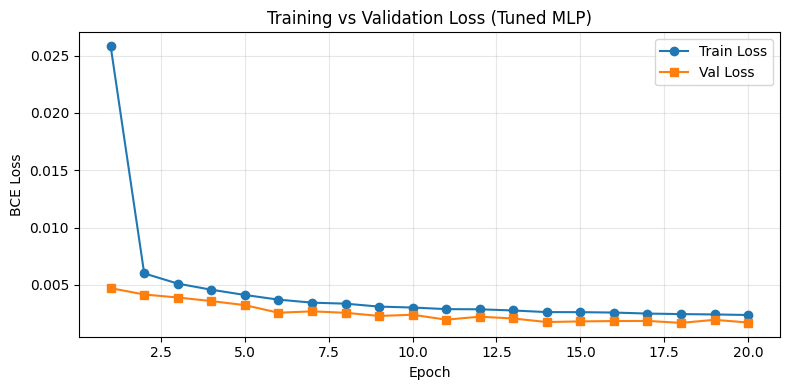

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', marker='o')
ax.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss', marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Training vs Validation Loss (Tuned MLP)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# XGB Learning Curve (train vs. val) --- No Overfitting plot

In [15]:
# custom functions

def sentinel_divide(n, d):
    sentinel = -1
    safe_d = np.where(d == 0, sentinel, d)
    return n / safe_d

In [16]:
df = pd.read_parquet("../../data/processed/preprocessed_minimal.parquet")
df.shape

(2294985, 94)

In [17]:
# NFI column sort
nfi_meta = ['stub_id', 'particle_id', 'class', 'label', 'target']
element_cols = [c for c in df.columns if c not in nfi_meta]
gsr = ['pb', 'sb', 'ba']
non_gsr = sorted([c for c in element_cols if c not in gsr])
nfi_df = df[nfi_meta + gsr + non_gsr]

print(f"# of elements: {len(element_cols)}")

# of elements: 89


In [18]:
eng_df = nfi_df.copy()

# Pb * Sb
eng_df['pb_times_sb'] = eng_df['pb'] * (eng_df['sb'])

# Log (Pb + Sb)
eng_df['log_pb_plus_sb'] = np.log1p(eng_df['pb'] + eng_df['sb'])

# GSR ratios over total mass
total_mass = eng_df[element_cols].sum(axis=1)
total_mass_no_sb = total_mass - eng_df['sb']
total_mass_no_ba = total_mass - eng_df['ba']
total_mass_no_pb = total_mass - eng_df['pb']

eng_df['pb_ba_over_non_sb_mass'] = (eng_df['pb'] + eng_df['ba']) / total_mass_no_sb
eng_df['pb_sb_over_non_ba_mass'] =  (eng_df['pb'] + eng_df['sb']) / total_mass_no_ba
eng_df['ba_sb_over_non_pb_mass'] =  (eng_df['ba'] + eng_df['sb']) / total_mass_no_pb

# Brass particles
eng_df['cu_zn_over_mass'] =  (eng_df['cu'] + eng_df['zn']) / total_mass

# Titanium Zinc
eng_df['ti_zn_over_mass'] = (eng_df['ti'] + eng_df['zn']) / total_mass

# Non-Barium GSR over Non-Barium Confounders
gsr = eng_df['pb'] + eng_df['sb']
confounders = eng_df['ca'] + eng_df['si'] + eng_df['al'] + eng_df['fe'] #+ eng_df['ti'] + eng_df['zn'] + eng_df['cu']
eng_df['gsr_over_confounders'] = sentinel_divide(gsr.values, confounders.values)

# check for any 'NaN' or 'inf'
any(np.isinf(eng_df['gsr_over_confounders']) | eng_df['gsr_over_confounders'].isna())

False

In [19]:
eng_cols = [c for c in eng_df.columns if c not in nfi_meta + element_cols]
print(f"# of engineered features: {len(eng_cols)}")
print(f"\nEngineered features:")
for feat in eng_cols:
    print(f"\t{feat}")

# of engineered features: 8

Engineered features:
	pb_times_sb
	log_pb_plus_sb
	pb_ba_over_non_sb_mass
	pb_sb_over_non_ba_mass
	ba_sb_over_non_pb_mass
	cu_zn_over_mass
	ti_zn_over_mass
	gsr_over_confounders


In [20]:
feature_cols = element_cols + eng_cols
print(f"# of feature columns: {len(feature_cols)}")

# of feature columns: 97


In [21]:
X = eng_df[feature_cols].values.astype(np.float32)
y = eng_df['target'].values.astype(np.float32)
groups = eng_df['stub_id'].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, y, groups))

X_trainval, X_test = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)  # 25% of 80% = 20% of total
train_idx_rel, val_idx_rel = next(gss2.split(X_trainval, y_trainval, groups_trainval))

X_train = X_trainval[train_idx_rel]
X_val = X_trainval[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]

groups_train = set(groups_trainval[train_idx_rel])
groups_val = set(groups_trainval[val_idx_rel])
groups_test = set(groups[test_idx])

In [22]:
# Verify no stub leakage
assert len(groups_train & groups_val) == 0, 'Train-Val stub leak!'
assert len(groups_train & groups_test) == 0, 'Train-Test stub leak!'
assert len(groups_val & groups_test) == 0, 'Val-Test stub leak!'

print("No stub-level leakage")

No stub-level leakage


In [23]:
total_obs = len(y_train) + len(y_val) + len(y_test)

summary = pd.DataFrame({
    "Split":         ["Train",          "Val",          "Test"],
    "Observations":  [len(y_train),     len(y_val),     len(y_test)],
    "% of Total":    [len(y_train)/total_obs*100, len(y_val)/total_obs*100, len(y_test)/total_obs*100],
    "GSR (target=1)":[int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "GSR %":         [y_train.mean()*100, y_val.mean()*100, y_test.mean()*100],
    "Unique Stubs":  [len(groups_train), len(groups_val), len(groups_test)],
})

summary["% of Total"] = summary["% of Total"].map("{:.1f}%".format)
summary["GSR %"]      = summary["GSR %"].map("{:.2f}%".format)

print(f"Total observations : {total_obs:,}")
print(f"Total features     : {X_train.shape[1]}")
print(f"Total unique stubs : {len(groups_train | groups_val | groups_test):,}\n")
print(summary.to_string(index=False))

Total observations : 2,294,985
Total features     : 97
Total unique stubs : 3,786

Split  Observations % of Total  GSR (target=1)  GSR %  Unique Stubs
Train       1444147      62.9%          717835 49.71%          2271
  Val        407614      17.8%          151162 37.08%           757
 Test        443224      19.3%          209949 47.37%           758


In [24]:
baseline = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', eval_metric='aucpr',
    early_stopping_rounds=30, random_state=42, n_jobs=-1,
)

baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=10
)

[0]	validation_0-aucpr:0.99971	validation_1-aucpr:0.99985
[10]	validation_0-aucpr:0.99980	validation_1-aucpr:0.99988
[20]	validation_0-aucpr:0.99989	validation_1-aucpr:0.99994
[30]	validation_0-aucpr:0.99997	validation_1-aucpr:0.99999
[40]	validation_0-aucpr:0.99999	validation_1-aucpr:0.99999
[50]	validation_0-aucpr:0.99999	validation_1-aucpr:1.00000
[60]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[70]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[80]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[90]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[100]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[110]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[120]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[130]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[140]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[150]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[160]	validation_0-aucpr:1.00000	validation_1-aucpr

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [25]:
results = baseline.evals_result()
train_aucpr = results['validation_0']['aucpr']
val_aucpr = results['validation_1']['aucpr']

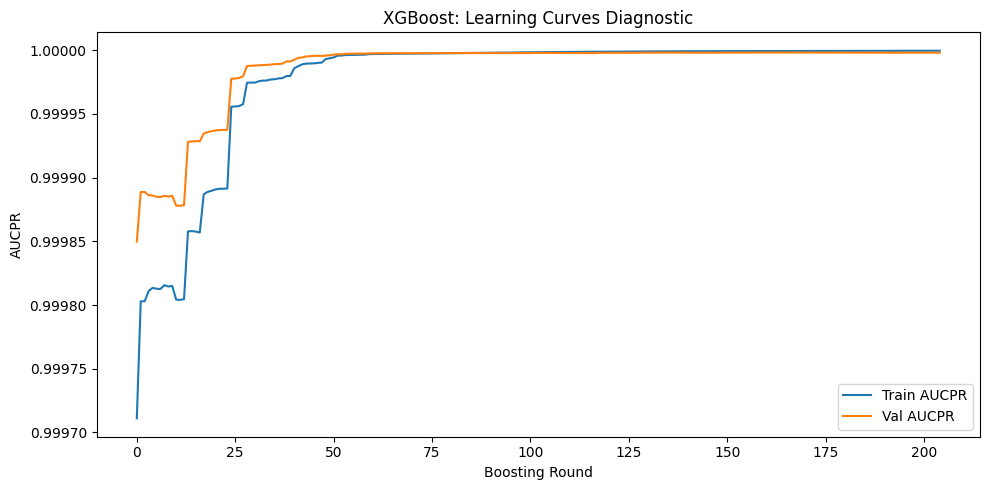

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_aucpr, label='Train AUCPR')
ax.plot(val_aucpr, label='Val AUCPR')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('AUCPR')
ax.set_title('XGBoost: Learning Curves Diagnostic')
ax.legend()
plt.tight_layout()
plt.savefig('xgb_learning_curves_final.png', dpi=150)
plt.show()

# Plots to Check for Overfitting & Ablation

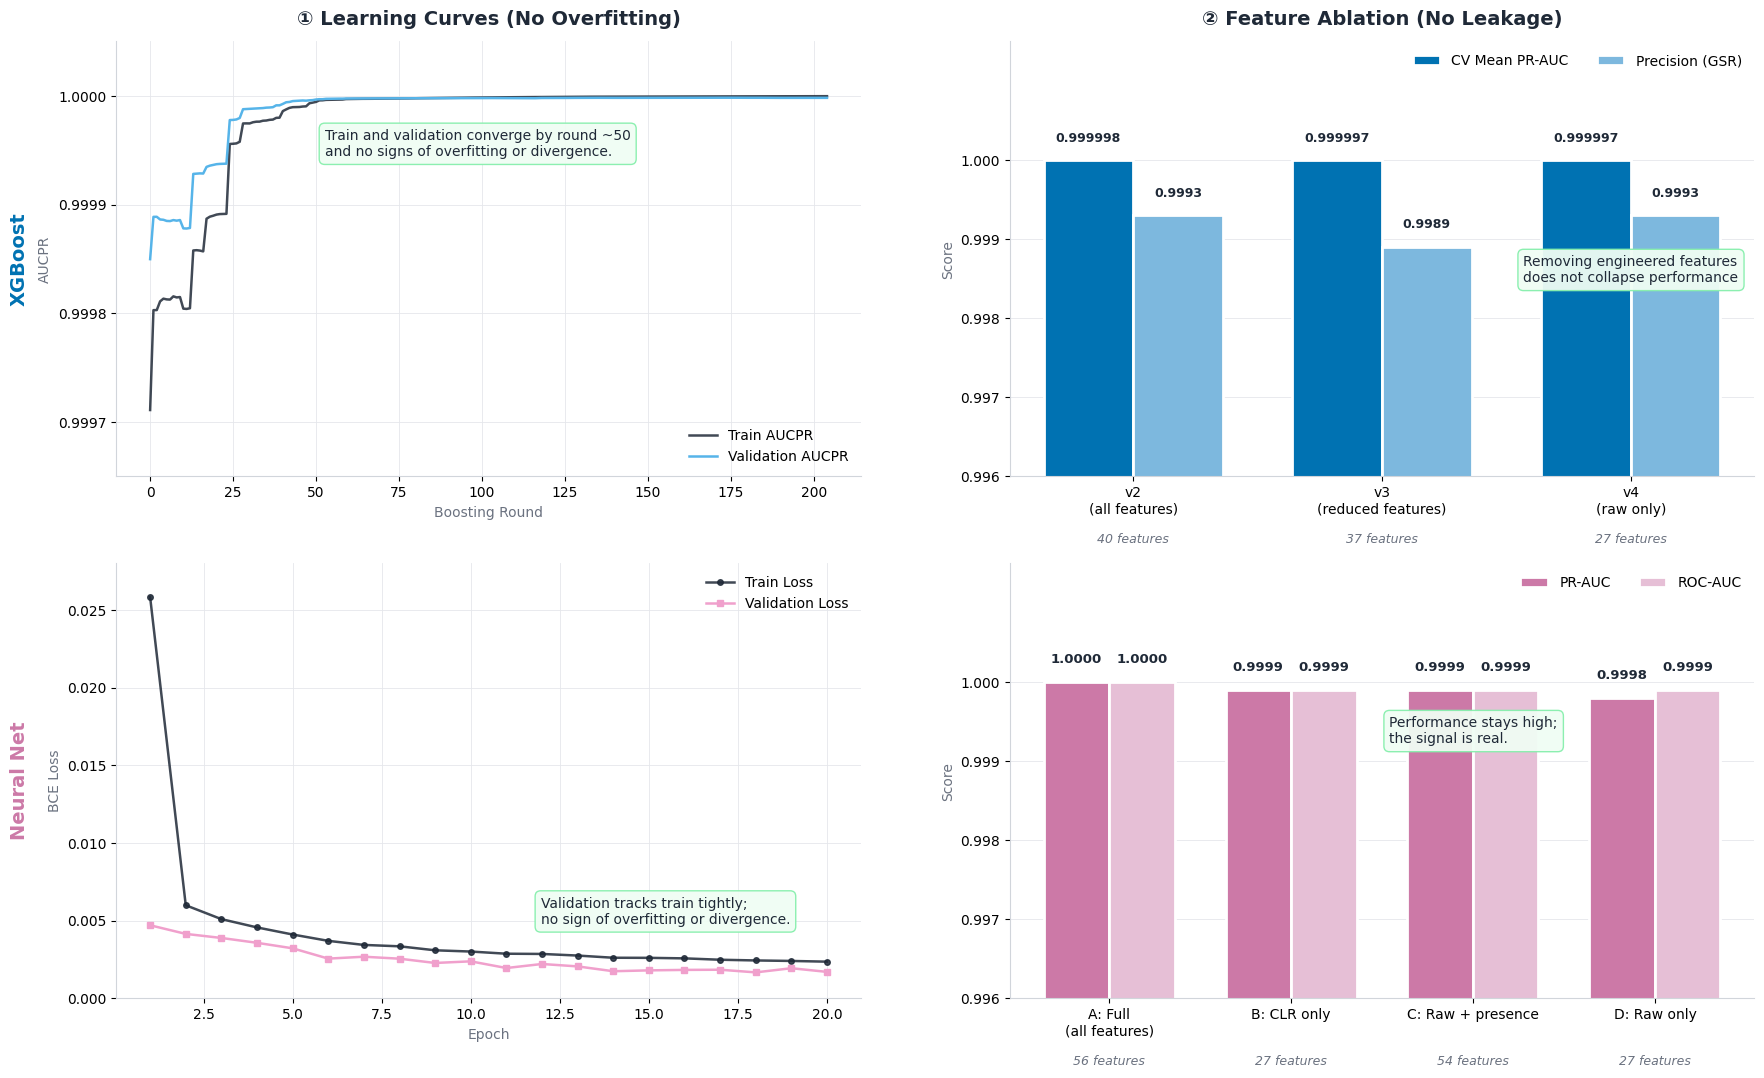

In [27]:
# ---------- Colors ----------
XGB_COLOR     = '#0072B2'  # Okabe-Ito blue
NN_COLOR      = '#CC79A7'  # Okabe-Ito magenta
TRAIN_COLOR   = '#1F2937'  # near-black for train line
VAL_COLOR_XGB = '#56B4E9'  # sky blue for XGB validation
VAL_COLOR_NN  = '#F0A0CC'  # lighter pink for NN validation
INK   = '#1F2937'
MUTED = '#6B7280'
GRID  = '#E5E7EB'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': '#D1D5DB',
})

# --- XGB ablation: v2 / v3 / v4 with CV Mean PR-AUC and Precision (GSR) ---
xgb_ablation = {
    'v2\n(all features)': {'pr_auc': 0.999998, 'precision': 0.9993, 'features': 40},
    'v3\n(reduced features)':  {'pr_auc': 0.999997, 'precision': 0.9989, 'features': 37},
    'v4\n(raw only)':   {'pr_auc': 0.999997, 'precision': 0.9993, 'features': 27},
}

# --- NN ablation: A/B/C/D with PR-AUC and ROC-AUC ---
nn_ablation = {
    'A: Full\n(all features)':   {'pr_auc': 1.0000, 'roc_auc': 1.0000, 'features': 56},
    'B: CLR only':               {'pr_auc': 0.9999, 'roc_auc': 0.9999, 'features': 27},
    'C: Raw + presence':         {'pr_auc': 0.9999, 'roc_auc': 0.9999, 'features': 54},
    'D: Raw only':               {'pr_auc': 0.9998, 'roc_auc': 0.9999, 'features': 27},
}

# =========================================================================
# Figure
# =========================================================================
fig = plt.figure(figsize=(18, 11), facecolor='white')
gs = GridSpec(
    nrows=2, ncols=2,
    height_ratios=[1.0, 1.0],
    hspace=0.20, wspace=0.20,
    left=0.06, right=0.97, top=0.93, bottom=0.06,
)

# =========================================================================
# Row 1, Col 1 XGBoost learning curve
# =========================================================================
ax = fig.add_subplot(gs[0, 0])
ax.set_title('① Learning Curves (No Overfitting)', fontsize=14, fontweight='bold', color=INK, pad=12, loc='center')
ax.plot(train_aucpr, color=TRAIN_COLOR, linewidth=1.8,
        label='Train AUCPR', alpha=0.85)
ax.plot(val_aucpr, color=VAL_COLOR_XGB, linewidth=1.8,
        label='Validation AUCPR')
ax.set_xlabel('Boosting Round', fontsize=10, color=MUTED)
ax.set_ylabel('AUCPR', fontsize=10, color=MUTED)
ax.set_ylim(0.99965, 1.00005)
ax.set_yticks([0.9997, 0.9998, 0.9999, 1.0000])
ax.set_yticklabels(['0.9997', '0.9998', '0.9999', '1.0000'])
ax.legend(loc='lower right', fontsize=10, frameon=False)
ax.grid(True, color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(-0.13, 0.5, 'XGBoost',
        rotation=90, ha='center', va='center', fontsize=14,
        fontweight='bold', color=XGB_COLOR, transform=ax.transAxes)

ax.text(0.28, 0.73,
        'Train and validation converge by round ~50\nand no signs of overfitting or divergence.',
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=10, color=INK,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0FDF4',
                  edgecolor='#86EFAC', linewidth=1, alpha=0.95))

# =========================================================================
# Row 1, Col 2 XGBoost ablation
# =========================================================================
ax = fig.add_subplot(gs[0, 1])
ax.set_title('② Feature Ablation (No Leakage)', fontsize=14, fontweight='bold', color=INK, pad=12, loc='center')
labels_xgb = list(xgb_ablation.keys())
pr_xgb     = [xgb_ablation[k]['pr_auc']    for k in labels_xgb]
acc_xgb    = [xgb_ablation[k]['precision'] for k in labels_xgb]
feats_xgb  = [xgb_ablation[k]['features']  for k in labels_xgb]

XGB_LIGHT = '#7DB8DE'
x_pos = np.arange(len(labels_xgb))
bar_w = 0.36

bars_pr  = ax.bar(x_pos - bar_w/2, pr_xgb,  bar_w, color=XGB_COLOR,
                  edgecolor='white', linewidth=2, label='CV Mean PR-AUC')
bars_acc = ax.bar(x_pos + bar_w/2, acc_xgb, bar_w, color=XGB_LIGHT,
                  edgecolor='white', linewidth=2, label='Precision (GSR)')

for bar, val in zip(bars_pr, pr_xgb):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0002,
            f'{val:.6f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=INK)
for bar, val in zip(bars_acc, acc_xgb):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0002,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=INK)

for xpos, n in zip(x_pos, feats_xgb):
    ax.text(xpos, -0.13, f'{n} features',
            ha='center', va='top', fontsize=9, color=MUTED, style='italic',
            transform=ax.get_xaxis_transform())

ax.set_xticks(x_pos)
ax.set_xticklabels(labels_xgb, fontsize=10)
ax.set_ylabel('Score', fontsize=10, color=MUTED)
ax.set_ylim(0.996, 1.0015)
ax.set_yticks([0.996, 0.997, 0.998, 0.999, 1.000])
ax.set_yticklabels(['0.996', '0.997', '0.998', '0.999', '1.000'])
ax.legend(loc='upper right', fontsize=10, frameon=False, ncol=2)
ax.grid(True, axis='y', color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(0.69, 0.44,
        'Removing engineered features\ndoes not collapse performance',
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=10, color=INK,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0FDF4',
                  edgecolor='#86EFAC', linewidth=1, alpha=0.95))

# =========================================================================
# Row 2, Col 1 Neural Net learning curve
# =========================================================================
ax = fig.add_subplot(gs[1, 0])
ax.plot(range(1, len(train_losses)+1), train_losses, color=TRAIN_COLOR, linewidth=1.8,
        marker='o', markersize=4, label='Train Loss', alpha=0.85)
ax.plot(range(1, len(val_losses)+1), val_losses, color=VAL_COLOR_NN, linewidth=1.8,
        marker='s', markersize=4, label='Validation Loss')
ax.set_xlabel('Epoch', fontsize=10, color=MUTED)
ax.set_ylabel('BCE Loss', fontsize=10, color=MUTED)
ax.set_ylim(0, 0.028)
ax.legend(loc='upper right', fontsize=10, frameon=False)
ax.grid(True, color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(-0.13, 0.5, 'Neural Net',
        rotation=90, ha='center', va='center', fontsize=14,
        fontweight='bold', color=NN_COLOR, transform=ax.transAxes)

ax.text(0.57, 0.20,
        'Validation tracks train tightly;\nno sign of overfitting or divergence.',
        transform=ax.transAxes, ha='left', va='center',
        fontsize=10, color=INK,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0FDF4',
                  edgecolor='#86EFAC', linewidth=1, alpha=0.95))

# =========================================================================
# Row 2, Col 2 NN ablation
# =========================================================================
ax = fig.add_subplot(gs[1, 1])
labels_nn = list(nn_ablation.keys())
vals_nn   = [nn_ablation[k]['pr_auc']  for k in labels_nn]
acc_nn    = [nn_ablation[k]['roc_auc'] for k in labels_nn]
feats_nn  = [nn_ablation[k]['features'] for k in labels_nn]

NN_LIGHT = '#E6BFD6'
x_pos_nn = np.arange(len(labels_nn))
bar_w = 0.36

bars_pr  = ax.bar(x_pos_nn - bar_w/2, vals_nn, bar_w, color=NN_COLOR,
                  edgecolor='white', linewidth=2, label='PR-AUC')
bars_acc = ax.bar(x_pos_nn + bar_w/2, acc_nn,  bar_w, color=NN_LIGHT,
                  edgecolor='white', linewidth=2, label='ROC-AUC')

for bar, val in zip(bars_pr, vals_nn):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0002,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color=INK)
for bar, val in zip(bars_acc, acc_nn):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0002,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color=INK)

for xpos, n in zip(x_pos_nn, feats_nn):
    ax.text(xpos, -0.13, f'{n} features',
            ha='center', va='top', fontsize=9, color=MUTED, style='italic',
            transform=ax.get_xaxis_transform())

ax.set_xticks(x_pos_nn)
ax.set_xticklabels(labels_nn, fontsize=10)
ax.set_ylabel('Score', fontsize=10, color=MUTED)
ax.set_ylim(0.9996, 1.0015)
ax.set_yticks([0.996, 0.997, 0.998, 0.999, 1.000])
ax.set_yticklabels(['0.996', '0.997', '0.998', '0.999', '1.000'])
ax.legend(loc='upper right', fontsize=10, frameon=False, ncol=2)
ax.grid(True, axis='y', color=GRID, linewidth=0.6)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(0.51, 0.58,
        'Performance stays high;\nthe signal is real.',
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=10, color=INK,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0FDF4',
                  edgecolor='#86EFAC', linewidth=1, alpha=0.95))

plt.show()

# Ambiguous Particles

## NN

The 506,682 ambiguous particles (Pb, Ba, Sb, Sr single-element classes) were excluded from training. Now we score them with the trained model to see how confidently it assigns them to GSR or Non-GSR. This directly addresses our research question about where automated classification breaks down and which particles need expert review.

In [29]:
df_amb = pd.read_parquet("../../data/processed/particle_ambiguous.parquet")
print(f"Ambiguous particles: {len(df_amb):,}")
print(f"Class distribution:")
print(df_amb["final_class"].value_counts())

Ambiguous particles: 506,682
Class distribution:
final_class
Sb    225676
Pb    168334
Ba     89277
Sr     23395
Name: count, dtype: int64


In [30]:
amb_meta = ["stub_id", "particle_id", "relevance_class", "merged_relevance_class", "final_class", "label"]
amb_element_cols = [c for c in df_amb.columns if c not in amb_meta]
print(f"\nElement columns: {len(amb_element_cols)}")


Element columns: 27


In [31]:
def multiplicative_replacement(X, delta=None):
    X = X.copy().astype(float)
    if delta is None:
        nonzero_vals = X[X > 0]
        delta = nonzero_vals.min() / 2 if len(nonzero_vals) > 0 else 1e-10
    row_sums = X.sum(axis=1, keepdims=True)
    for i in range(X.shape[0]):
        zero_mask = X[i] == 0
        n_zeros = zero_mask.sum()
        if n_zeros > 0 and row_sums[i, 0] > 0:
            X[i, zero_mask] = delta
            correction = 1 - (n_zeros * delta / row_sums[i, 0])
            X[i, ~zero_mask] *= correction
    return X

def clr_transform(X):
    log_X = np.log(X)
    geometric_mean = log_X.mean(axis=1, keepdims=True)
    return log_X - geometric_mean

In [32]:
X_amb_raw = df_amb[amb_element_cols].values
X_amb_replaced = multiplicative_replacement(X_amb_raw)
X_amb_clr = clr_transform(X_amb_replaced)
X_amb_presence = (X_amb_raw > 0).astype(np.float32)

total_mass = df_amb[amb_element_cols].sum(axis=1).values
denom = total_mass - df_amb["ba"].values - df_amb["o"].values
safe_denom = np.where(denom == 0, -1, denom)
pb_sb_ratio = ((df_amb["pb"].values + df_amb["sb"].values) / safe_denom).astype(np.float32)
log_pb_sb = np.log1p(df_amb["pb"].values + df_amb["sb"].values).astype(np.float32)

X_amb_features = np.hstack([
    X_amb_clr.astype(np.float32),
    X_amb_presence,
    pb_sb_ratio.reshape(-1, 1),
    log_pb_sb.reshape(-1, 1)
])

print(f"Ambiguous feature matrix: {X_amb_features.shape}")
print(f"Expected: ({len(df_amb)}, {len(feature_cols)})")

Ambiguous feature matrix: (506682, 56)
Expected: (506682, 97)


In [33]:
#scale with the same scaler fit on training data
X_amb_scaled = scaler.transform(X_amb_features)

model.eval()
with torch.no_grad():
    amb_logits = model(torch.tensor(X_amb_scaled, dtype=torch.float32).to(device)).squeeze().cpu().numpy()
amb_probs = 1 / (1 + np.exp(-amb_logits))
amb_preds = (amb_probs >= 0.5).astype(int)

print(f"Ambiguous particles scored: {len(amb_probs):,}")

Ambiguous particles scored: 506,682


In [34]:
amb_results = []
for cls in sorted(df_amb["final_class"].unique()):
    mask = df_amb["final_class"].values == cls
    n = mask.sum()
    cls_probs = amb_probs[mask]
    cls_preds = amb_preds[mask]
    amb_results.append({
        "Class": cls,
        "N": f"{n:,}",
        "Pred GSR %": f"{cls_preds.mean():.1%}",
        "Mean P(GSR)": f"{cls_probs.mean():.4f}",
        "Median P(GSR)": f"{np.median(cls_probs):.4f}",
        "P(GSR) < 0.2": f"{(cls_probs < 0.2).mean():.1%}",
        "0.2 < P < 0.8": f"{((cls_probs >= 0.2) & (cls_probs <= 0.8)).mean():.1%}",
        "P(GSR) > 0.8": f"{(cls_probs > 0.8).mean():.1%}",
    })

print("Model predictions on ambiguous particles:")
print(pd.DataFrame(amb_results).to_string(index=False))

Model predictions on ambiguous particles:
Class       N Pred GSR % Mean P(GSR) Median P(GSR) P(GSR) < 0.2 0.2 < P < 0.8 P(GSR) > 0.8
   Ba  89,277       0.5%      0.0049        0.0000        99.4%          0.2%         0.4%
   Pb 168,334       2.0%      0.0200        0.0000        97.9%          0.3%         1.8%
   Sb 225,676       3.9%      0.0427        0.0000        94.4%          3.0%         2.6%
   Sr  23,395       0.2%      0.0018        0.0000        99.8%          0.0%         0.2%


## XGB

In [37]:
nfi_df = pd.read_parquet("../../data/raw/NFI/nfi_particle_data_full.parquet")
nfi_df.shape

(2801667, 106)

In [38]:
element_cols = [c for c in nfi_df.columns if 1 <= len(c) <= 2]
filtered = nfi_df[['stub_id', 'particle_id', 'merged_relevance_class'] + element_cols]
filtered = filtered.drop(columns='id')  # remove 'id' if it was included
element_cols = [c for c in filtered.columns if 1 <= len(c) <= 2]
len(element_cols)

89

In [39]:
amb_89 = filtered[filtered['merged_relevance_class'].isin(['Sb', 'Pb', 'Ba', 'Sr', 'BaSi', 'BaSn', 'BaSr'])]
amb_89.shape

(506682, 92)

In [40]:
amb_89 = (
    amb_89
    .rename(columns={'merged_relevance_class': 'final_class'})
    .assign(final_class=lambda d: d['final_class'].replace({'BaSn': 'Ba'}))
)

print(amb_89["final_class"].value_counts())

final_class
Sb    225676
Pb    168334
Ba     89277
Sr     23395
Name: count, dtype: int64


In [41]:
amb_89['label'] = 'Ambiguous'

In [43]:
df_amb = pd.read_parquet("../../data/processed/particle_ambiguous.parquet")
print(f"Ambiguous particles: {len(df_amb):,}")
print(f"Class distribution:")
print(df_amb["final_class"].value_counts())

Ambiguous particles: 506,682
Class distribution:
final_class
Sb    225676
Pb    168334
Ba     89277
Sr     23395
Name: count, dtype: int64


__Rejoin original ambiguous dataset w/ preprocessed ambiguous dataset (all 89 elements)__

In [44]:
keys = ['stub_id', 'particle_id']
drop_extra = ['relevance_class', 'merged_relevance_class']

# columns in df_amb that overlap with amb_89 (other than the keys) -> drop from df_amb to avoid dupes
overlap = [c for c in df_amb.columns if c in amb_89.columns and c not in keys]
df_amb_trim = df_amb.drop(columns=overlap)

merged = amb_89.merge(df_amb_trim, on=keys, how='inner')
merged = merged.drop(columns=[c for c in drop_extra if c in merged.columns])
print(f"Merged dataset shape: {merged.shape}")

Merged dataset shape: (506682, 93)


In [45]:
amb_meta_cols = ['stub_id', 'particle_id', 'final_class', 'label']
amb_element_cols = [c for c in merged.columns if c not in amb_meta_cols]
len(amb_element_cols)

89

In [46]:
eng_amb = merged.copy()

# Pb * Sb
eng_amb['pb_times_sb'] = eng_amb['pb'] * (eng_amb['sb'])

# Log (Pb + Sb)
eng_amb['log_pb_plus_sb'] = np.log1p(eng_amb['pb'] + eng_amb['sb'])

# GSR ratios over total mass
total_mass = eng_amb[element_cols].sum(axis=1)
total_mass_no_sb = total_mass - eng_amb['sb']
total_mass_no_ba = total_mass - eng_amb['ba']
total_mass_no_pb = total_mass - eng_amb['pb']

eng_amb['pb_ba_over_non_sb_mass'] = (eng_amb['pb'] + eng_amb['ba']) / total_mass_no_sb
eng_amb['pb_sb_over_non_ba_mass'] =  (eng_amb['pb'] + eng_amb['sb']) / total_mass_no_ba
eng_amb['ba_sb_over_non_pb_mass'] =  (eng_amb['ba'] + eng_amb['sb']) / total_mass_no_pb

# Brass particles
eng_amb['cu_zn_over_mass'] =  (eng_amb['cu'] + eng_amb['zn']) / total_mass

# Titanium Zinc
eng_amb['ti_zn_over_mass'] = (eng_amb['ti'] + eng_amb['zn']) / total_mass

# Non-Barium GSR over Non-Barium Confounders
gsr = eng_amb['pb'] + eng_amb['sb']
confounders = eng_amb['ca'] + eng_amb['si'] + eng_amb['al'] + eng_amb['fe'] #+ eng_amb['ti'] + eng_amb['zn'] + eng_amb['cu']
eng_amb['gsr_over_confounders'] = sentinel_divide(gsr.values, confounders.values)

# check for any 'NaN' or 'inf'
any(np.isinf(eng_amb['gsr_over_confounders']) | eng_amb['gsr_over_confounders'].isna())



False

In [47]:
eng_amb_cols = [c for c in eng_amb.columns if c not in amb_meta_cols + amb_element_cols]
print(f"# of engineered features: {len(eng_amb_cols)}")
print(f"\nEngineered features:")
for feat in eng_amb_cols:
    print(f"\t{feat}")

# of engineered features: 8

Engineered features:
	pb_times_sb
	log_pb_plus_sb
	pb_ba_over_non_sb_mass
	pb_sb_over_non_ba_mass
	ba_sb_over_non_pb_mass
	cu_zn_over_mass
	ti_zn_over_mass
	gsr_over_confounders


In [48]:
feature_amb_cols = amb_element_cols + eng_amb_cols
print(f"# of feature columns: {len(feature_amb_cols)}")

# of feature columns: 97


__Run XGBoost Model against Ambiguous Particles__

In [49]:
xgb_model = baseline
X_amb = eng_amb[feature_amb_cols].values.astype(np.float32)

probs_amb = xgb_model.predict_proba(X_amb)[:, 1]
preds_amb = (probs_amb >= 0.94).astype(int)

eng_amb = eng_amb.assign(prob_gsr=probs_amb, pred_gsr=preds_amb)

n = len(eng_amb)
n_gsr = int(preds_amb.sum())
print(f'Particles scored : {n:,}')
print(f'Predicted GSR    : {n_gsr:,}  ({n_gsr / n:.1%})')
print(f'Predicted Non-GSR: {n - n_gsr:,}  ({1 - n_gsr / n:.1%})')
print(f'\nProbability distribution:')
print(pd.Series(probs_amb).describe(percentiles=[.1, .25, .5, .75, .9, .95]).round(4))
print(f'\nPredicted GSR by final_class:')
agg = (
    eng_amb.groupby('final_class')
           .agg(n=('pred_gsr', 'size'),
                pred_gsr=('pred_gsr', 'sum'),
                mean_prob=('prob_gsr', 'mean'))
)
agg['pct_gsr'] = agg['pred_gsr'] / agg['n'] * 100
agg = agg.sort_values('pct_gsr', ascending=False)
print(agg.round(2))

Particles scored : 506,682
Predicted GSR    : 22,016  (4.3%)
Predicted Non-GSR: 484,666  (95.7%)

Probability distribution:
count    506682.0000
mean          0.2958
std           0.3593
min           0.0000
10%           0.0000
25%           0.0005
50%           0.1032
75%           0.6960
90%           0.8831
95%           0.9304
max           1.0000
dtype: float64

Predicted GSR by final_class:
                  n  pred_gsr  mean_prob  pct_gsr
final_class                                      
Sb           225676     21006       0.57     9.31
Pb           168334       710       0.13     0.42
Ba            89277       298       0.00     0.33
Sr            23395         2       0.00     0.01


In [50]:
print(f'Overall pct_gsr (manual): {eng_amb["pred_gsr"].mean() * 100:.2f}%')
print(f'Weighted from agg:        {(agg["pred_gsr"].sum() / agg["n"].sum()) * 100:.2f}%')
print(agg[["n", "pred_gsr", "pct_gsr"]])

Overall pct_gsr (manual): 4.35%
Weighted from agg:        4.35%
                  n  pred_gsr   pct_gsr
final_class                            
Sb           225676     21006  9.308035
Pb           168334       710  0.421781
Ba            89277       298  0.333793
Sr            23395         2  0.008549


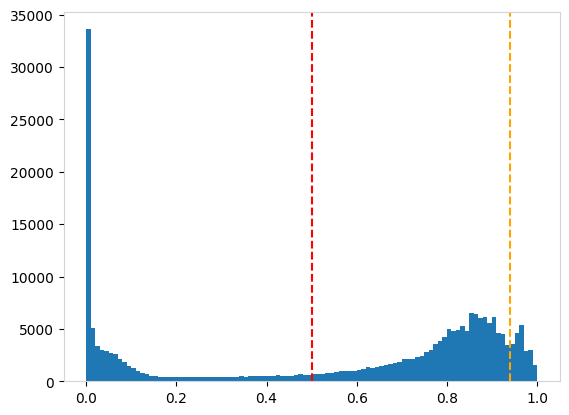

In [51]:
sb_mask = (eng_amb['final_class'] == 'Sb')
sb_flagged = eng_amb[sb_mask & (eng_amb['pred_gsr'] == 1)]
sb_not_flagged = eng_amb[sb_mask & (eng_amb['pred_gsr'] == 0)]

sb_probs = probs_amb[sb_mask]
plt.hist(sb_probs, bins=100)
plt.axvline(0.5, color='red', linestyle='--')
plt.axvline(0.94, color='orange', linestyle='--', label='your threshold')

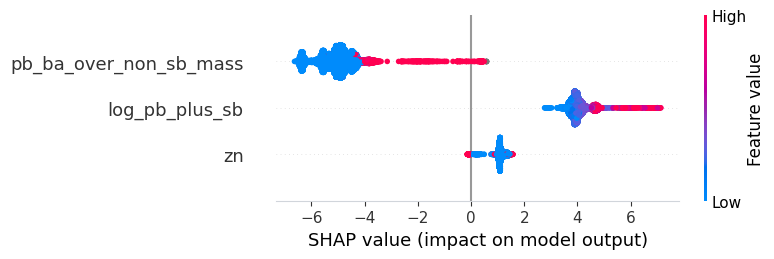

In [54]:
sb_flagged_idx = np.where(sb_mask & (preds_amb == 1))[0]

amb_explainer = shap.TreeExplainer(xgb_model)

shap_values_sb = amb_explainer.shap_values(X_amb[sb_flagged_idx])
shap.summary_plot(shap_values_sb, X_amb[sb_flagged_idx], feature_names=feature_amb_cols, max_display=3)

In [55]:
# Antimony SHAP attribution for the ambiguous GSR predictions.
# For every Sb-class particle that the model flagged as GSR, list the top 3
# features pushing the prediction toward GSR (largest positive SHAP).
sb_flagged_idx = np.where(sb_mask & (preds_amb == 1))[0]
print(f"Computing SHAP for {len(sb_flagged_idx)} Sb particles flagged as GSR...")

shap_sb = amb_explainer.shap_values(X_amb[sb_flagged_idx])

eng_amb_reset = eng_amb.reset_index(drop=True)
sb_records = []
for i, idx in enumerate(sb_flagged_idx):
    row = eng_amb_reset.iloc[idx]
    contributions = pd.Series(shap_sb[i], index=feature_amb_cols)
    top_pos = contributions.nlargest(3)
    sb_records.append({
        'stub_id': row['stub_id'],
        'particle_id': row['particle_id'],
        'final_class': row['final_class'],
        'prob': probs_amb[idx],
        'top_feature_1': top_pos.index[0],
        'shap_1': top_pos.iloc[0],
        'top_feature_2': top_pos.index[1],
        'shap_2': top_pos.iloc[1],
        'top_feature_3': top_pos.index[2],
        'shap_3': top_pos.iloc[2],
    })
sb_shap_df = pd.DataFrame(sb_records).sort_values('prob', ascending=False)
print("Top-15 highest-confidence Sb-flagged particles with SHAP attribution:")
print(sb_shap_df.head(15).to_string(index=False))
sb_shap_df.to_csv('xgb_sb_amb_shap_attribution.csv', index=False)

# Aggregate: which features most often drive these Sb-class flags?
sb_top_feature_counts = sb_shap_df['top_feature_1'].value_counts()
print(f"Which features most often drive Sb-class GSR flags (top-1 SHAP):")
print(sb_top_feature_counts.head(10))


Computing SHAP for 21006 Sb particles flagged as GSR...
Top-15 highest-confidence Sb-flagged particles with SHAP attribution:
 stub_id  particle_id final_class     prob  top_feature_1   shap_1          top_feature_2   shap_2          top_feature_3   shap_3
    1341         7776          Sb 0.999998 log_pb_plus_sb 7.079923                     sb 1.400339 pb_sb_over_non_ba_mass 1.258536
    1341         7772          Sb 0.999998 log_pb_plus_sb 7.064093                     sb 1.381587 pb_sb_over_non_ba_mass 1.247355
     180         5853          Sb 0.999997 log_pb_plus_sb 7.035996 pb_sb_over_non_ba_mass 1.298524                     sb 1.240487
     180         6463          Sb 0.999997 log_pb_plus_sb 7.127329 pb_sb_over_non_ba_mass 1.323624                     sb 1.212834
     773         3320          Sb 0.999997 log_pb_plus_sb 7.048700 pb_sb_over_non_ba_mass 1.286062                     sb 1.243230
    2795         1494          Sb 0.999997 log_pb_plus_sb 6.902392                     s

### Ambiguous Particle Viz

In [64]:
for cls in ['Sb', 'Pb', 'Ba', 'Sr']:
    p = probs_amb[eng_amb['final_class'] == cls]
    print(cls,
          (p < 0.5).mean(),
          ((p >= 0.5) & (p < 0.94)).mean(),
          (p >= 0.94).mean())

Sb 0.350218897889009 0.5567007568372356 0.09308034527375529
Pb 0.9577506623736144 0.03803153254838595 0.004217805077999691
Ba 0.9956091714551341 0.001052902763309699 0.00333792578155628
Sr 0.9986749305407139 0.0012395811070741612 8.548835221201111e-05


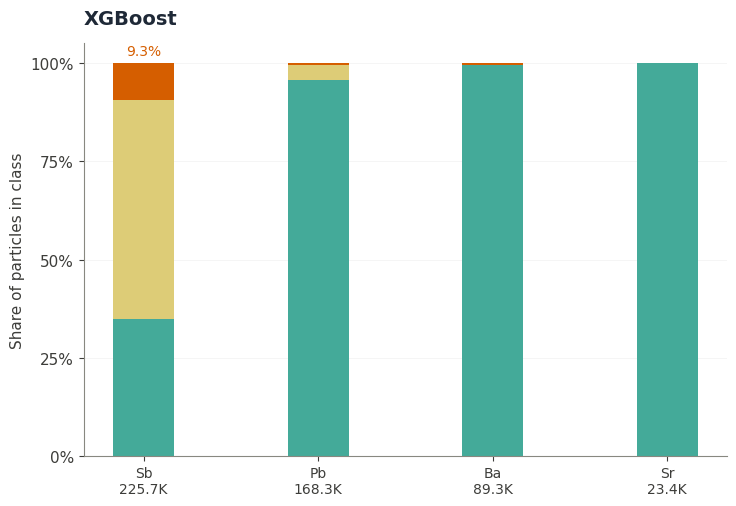

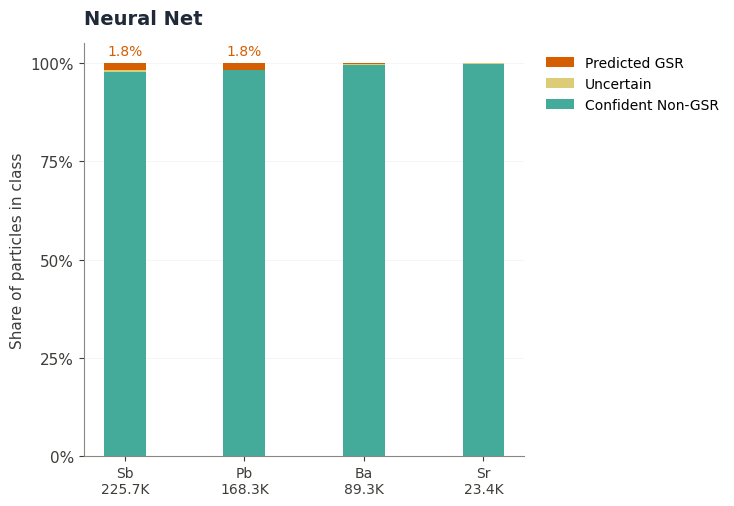

In [75]:
"""
Ambiguous Particles — Confidence Breakdown
XGBoost and NN predictions on 506,682 single-element particles excluded from training.

Two separate figures (XGB and NN), each with one bar per class (Sb, Pb, Ba, Sr),
segmented by confidence band. The thresholds differ between models:
  XGB: P < 0.5 / 0.5 <= P < 0.94 / P >= 0.94
  NN : P < 0.2 / 0.2 <= P <= 0.8 / P > 0.8
"""

# --- Data -------------------------------------------------------------------

classes = ['Sb', 'Pb', 'Ba', 'Sr']
n_per_class = [225676, 168334, 89277, 23395]

# Neural Network — from Table 9 in the Baseline report (P<0.2 / 0.2-0.8 / >0.8)
nn_conf_non = [97.8, 98.2, 99.5, 99.8]
nn_uncertain = [0.4, 0.0, 0.2, 0.1]
nn_pred_gsr = [1.8, 1.8, 0.3, 0.0]

# XGBoost (calculated in previous cell)
xgb_conf_non = [35.0, 95.8, 99.6, 99.9]
xgb_uncertain = [55.7, 3.8, 0.01, 0.1]
xgb_pred_gsr = [9.3, 0.4, 0.3, 0.0]

# --- Style ------------------------------------------------------------------

# Colorblind-safe traffic-light palette
color_non = "#44AA99"   # Tol muted teal-green - confident Non-GSR
color_unc = "#DDCC77"   # Tol sandy yellow - uncertain
color_gsr = "#D55E00"   # Okabe-Ito vermillion - predicted GSR

plt.rcParams.update({
    "font.size": 11,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#888880",
    "axes.labelcolor": "#3d3d3a",
    "xtick.color": "#3d3d3a",
    "ytick.color": "#3d3d3a",
})

# --- Plot helper ------------------------------------------------------------

def plot_confidence(conf_non, uncertain, pred_gsr, title, title_color, band_labels, show_legend=True):
    fig, ax = plt.subplots(figsize=(7.5, 5.2))
    x = np.arange(len(classes))
    bar_w = 0.35

    ax.bar(x, conf_non, bar_w, color=color_non, label=band_labels[0])
    ax.bar(x, uncertain, bar_w, bottom=conf_non, color=color_unc, label=band_labels[1])
    bottoms_gsr = [c + u for c, u in zip(conf_non, uncertain)]
    ax.bar(x, pred_gsr, bar_w, bottom=bottoms_gsr, color=color_gsr, label=band_labels[2])

    ax.set_title(title, fontsize=14, fontweight="bold", pad=14, loc="left", color=title_color)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c}\n{n/1000:.1f}K" for c, n in zip(classes, n_per_class)], fontsize=10)
    ax.set_ylim(0, 105)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.set_ylabel("Share of particles in class", fontsize=11)
    ax.grid(axis="y", alpha=0.18, linewidth=0.5)
    ax.set_axisbelow(True)

    for i, (cn, un, gs) in enumerate(zip(conf_non, uncertain, pred_gsr)):
        if gs >= 1.0:
            ax.annotate(f"{gs:.1f}%",
                        xy=(i, cn + un + gs),
                        xytext=(0, 6), textcoords="offset points",
                        ha="center", fontsize=10, fontweight="medium",
                        color=color_gsr)

    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles[::-1], labels=labels[::-1],
                  loc="upper left", bbox_to_anchor=(1.02, 1.0),
                  ncol=1, frameon=False, fontsize=10)

    plt.tight_layout()
    plt.show()

# --- XGBoost ----------------------------------------------------------------
plot_confidence(
    xgb_conf_non, xgb_uncertain, xgb_pred_gsr,
    title="XGBoost",
    title_color=INK,
    band_labels=[
        "Confident Non-GSR",
        "Uncertain",
        "Predicted GSR",
    ],
    show_legend=False,
)

# --- Neural Network ---------------------------------------------------------
plot_confidence(
    nn_conf_non, nn_uncertain, nn_pred_gsr,
    title="Neural Net",
    title_color=INK,
    band_labels=[
        "Confident Non-GSR",
        "Uncertain",
        "Predicted GSR",
    ],
)

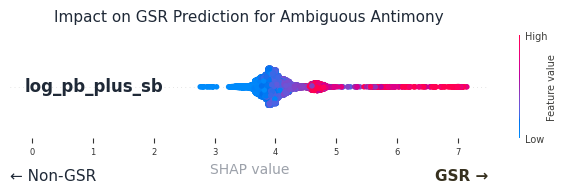

In [103]:
sb_flagged_idx = np.where(sb_mask & (preds_amb == 1))[0]

amb_explainer = shap.TreeExplainer(xgb_model)
shap_values_sb = amb_explainer.shap_values(X_amb[sb_flagged_idx])

# Slice down to just log_pb_plus_sb
log_idx = feature_amb_cols.index("log_pb_plus_sb")
shap_subset = shap_values_sb[:, [log_idx]]
X_subset    = X_amb[sb_flagged_idx][:, [log_idx]]

shap.summary_plot(
    shap_subset, X_subset,
    feature_names=["log_pb_plus_sb"], show=False,
)

fig = plt.gcf()
ax = plt.gca()

# Drop the default y-tick label, put feature name inside the plot just right of the y-axis
ax.set_title("Impact on GSR Prediction for Ambiguous Antimony", fontsize=11, color="#1F2937", pad=10)
ax.set_yticklabels([])
ax.text(0.03, 0.5, "log_pb_plus_sb", transform=ax.transAxes,
        ha="left", va="center", fontsize=12, fontweight="bold", color="#1F2937")

# Trim the x-axis label
ax.set_xlabel("SHAP value", fontsize=10, color="#9CA1AA")

# Hide the y-axis spine and tick marks (label stays)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", labelsize=6)

# SHAP draws an axvline at x=0 — remove it
for line in list(ax.lines):
    xd = np.asarray(line.get_xdata())
    if xd.size > 0 and np.allclose(xd, 0):
        line.remove()

# Shrink the colorbar text ("Feature value", "High", "Low")
if len(fig.axes) > 1:
    cbar_ax = fig.axes[-1]
    cbar_ax.tick_params(labelsize=7)
    if cbar_ax.get_ylabel():
        cbar_ax.set_ylabel(cbar_ax.get_ylabel(), fontsize=7)

# GSR / Non-GSR direction cues
ax.text(0.0, -0.30, "← Non-GSR", transform=ax.transAxes,
        ha="left", va="top", fontsize=11, color="#1F2937")
ax.text(1.0, -0.30, "GSR →", transform=ax.transAxes,
        ha="right", va="top", fontsize=11, fontweight="bold", color="#37311F")

plt.show()
